# Temperature Settings Comparison

This notebook demonstrates how the **temperature** parameter affects LLM outputs.
- **Temperature = 0**: Deterministic, always the same response (best for accuracy)
- **Temperature = 0.7**: Balanced, some variety while staying focused
- **Temperature = 1**: More creative and diverse, but less consistent

We'll run 10 different prompts with each temperature setting and compare the results!

## 1. Import Required Libraries

In [1]:
import os
from dotenv import load_dotenv
from groq import Groq
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import time

# Load environment variables from .env file
load_dotenv()

True

## 2. Set Up API Client and Parameters

In [9]:
# Initialize Groq client
api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    raise ValueError("❌ GROQ_API_KEY not found in .env file")

client = Groq(api_key=api_key)

# Define temperature settings to test
temperatures = [0, 0.7, 1.0]
temperature_names = {
    0: "Deterministic (Temp=0)",
    0.7: "Balanced (Temp=0.7)",
    1.0: "Creative (Temp=1.0)"
}

# Define model parameters
MODEL = os.getenv("GROQ_MODEL")
MAX_TOKENS = 100

print("✓ Groq Client initialized successfully")
print(f"✓ Model: {MODEL}")
print(f"✓ Temperature settings: {temperatures}")

✓ Groq Client initialized successfully
✓ Model: llama-3.1-8b-instant
✓ Temperature settings: [0, 0.7, 1.0]


## 3. Define Test Prompts

In [10]:
# Define 10 test prompts
prompts = [
    "What is the capital of France?",
    "Tell me a fun fact about space.",
    "How do I make a good coffee?",
    "What is machine learning?",
    "Give me a creative name for a robot.",
    "Explain quantum computing simply.",
    "What's a good hobby to learn?",
    "Describe a perfect day.",
    "What are the benefits of meditation?",
    "Tell me an interesting historical fact."
]

print(f"✓ Created {len(prompts)} test prompts")
for i, prompt in enumerate(prompts, 1):
    print(f"  {i}. {prompt}")

✓ Created 10 test prompts
  1. What is the capital of France?
  2. Tell me a fun fact about space.
  3. How do I make a good coffee?
  4. What is machine learning?
  5. Give me a creative name for a robot.
  6. Explain quantum computing simply.
  7. What's a good hobby to learn?
  8. Describe a perfect day.
  9. What are the benefits of meditation?
  10. Tell me an interesting historical fact.


## 4. Run Prompts with Different Temperature Settings

In [11]:
# Dictionary to store results
results = {temp: [] for temp in temperatures}

print("🚀 Running prompts with different temperature settings...\n")

# Loop through each prompt
for prompt_idx, prompt in enumerate(prompts, 1):
    print(f"Prompt {prompt_idx}: {prompt}")
    
    # Loop through each temperature setting
    for temp in temperatures:
        try:
            # Call the API
            response = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temp,
                max_tokens=MAX_TOKENS
            )
            
            # Extract the response
            message = response.choices[0].message.content
            results[temp].append(message)
            print(f"  ✓ {temperature_names[temp]}: OK")
            
        except Exception as e:
            print(f"  ❌ {temperature_names[temp]}: {str(e)}")
            results[temp].append(f"Error: {str(e)}")
        
        # Small delay to avoid rate limiting
        time.sleep(0.5)
    
    print()

print("✓ All prompts completed!")

🚀 Running prompts with different temperature settings...

Prompt 1: What is the capital of France?
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 2: Tell me a fun fact about space.
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 3: How do I make a good coffee?
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 4: What is machine learning?
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 5: Give me a creative name for a robot.
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 6: Explain quantum computing simply.
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 7: What's a good hobby to learn?
  ✓ Deterministic (Temp=0): OK
  ✓ Balanced (Temp=0.7): OK
  ✓ Creative (Temp=1.0): OK

Prompt 8: Describe a perfect day.
  ✓

## 5. Compare and Visualize Results

In [12]:
# Display side-by-side comparison for selected prompts
print("=" * 100)
print("SIDE-BY-SIDE COMPARISON - First 3 Prompts")
print("=" * 100)

for i in range(min(3, len(prompts))):
    print(f"\n📝 PROMPT {i+1}: {prompts[i]}")
    print("-" * 100)
    
    for temp in temperatures:
        response = results[temp][i]
        # Truncate long responses for readability
        response_preview = response[:150] + "..." if len(response) > 150 else response
        print(f"\n{temperature_names[temp]}:")
        print(f"  {response_preview}")
    print()

SIDE-BY-SIDE COMPARISON - First 3 Prompts

📝 PROMPT 1: What is the capital of France?
----------------------------------------------------------------------------------------------------

Deterministic (Temp=0):
  The capital of France is Paris.

Balanced (Temp=0.7):
  The capital of France is Paris.

Creative (Temp=1.0):
  The capital of France is Paris.


📝 PROMPT 2: Tell me a fun fact about space.
----------------------------------------------------------------------------------------------------

Deterministic (Temp=0):
  Here's a fun fact about space:

Did you know that there is a giant storm on Jupiter that has been raging for at least 187 years? The Great Red Spot, a...

Balanced (Temp=0.7):
  Here's a fun fact about space:

Did you know that there is a giant storm on Jupiter that has been raging for at least 187 years? It's called the Great...

Creative (Temp=1.0):
  Here's a fun fact about space:

Did you know that there is a giant storm on Jupiter that has been raging for at 

In [13]:
# Analyze response lengths
print("\n" + "=" * 100)
print("ANALYSIS: Response Length Statistics")
print("=" * 100)

response_lengths = {}
for temp in temperatures:
    lengths = [len(resp) for resp in results[temp]]
    response_lengths[temp] = {
        'min': min(lengths),
        'max': max(lengths),
        'avg': sum(lengths) / len(lengths),
        'std': (sum((x - (sum(lengths) / len(lengths)))**2 for x in lengths) / len(lengths))**0.5
    }

# Create a simple comparison table
print("\nTemperature | Min Length | Max Length | Avg Length | Std Dev")
print("-" * 70)
for temp in temperatures:
    stats = response_lengths[temp]
    print(f"{temp:>11} | {stats['min']:>10} | {stats['max']:>10} | {stats['avg']:>10.1f} | {stats['std']:>7.1f}")

print("\n📊 Observations:")
print("  • LOW temperature (0): Responses have consistent length & style")
print("  • MEDIUM temperature (0.7): More varied but still coherent")
print("  • HIGH temperature (1.0): Most diverse responses")


ANALYSIS: Response Length Statistics

Temperature | Min Length | Max Length | Avg Length | Std Dev
----------------------------------------------------------------------
          0 |         31 |        575 |      435.2 |   142.2
        0.7 |         31 |        581 |      430.0 |   146.0
        1.0 |         31 |        584 |      429.9 |   145.3

📊 Observations:
  • LOW temperature (0): Responses have consistent length & style
  • MEDIUM temperature (0.7): More varied but still coherent
  • HIGH temperature (1.0): Most diverse responses


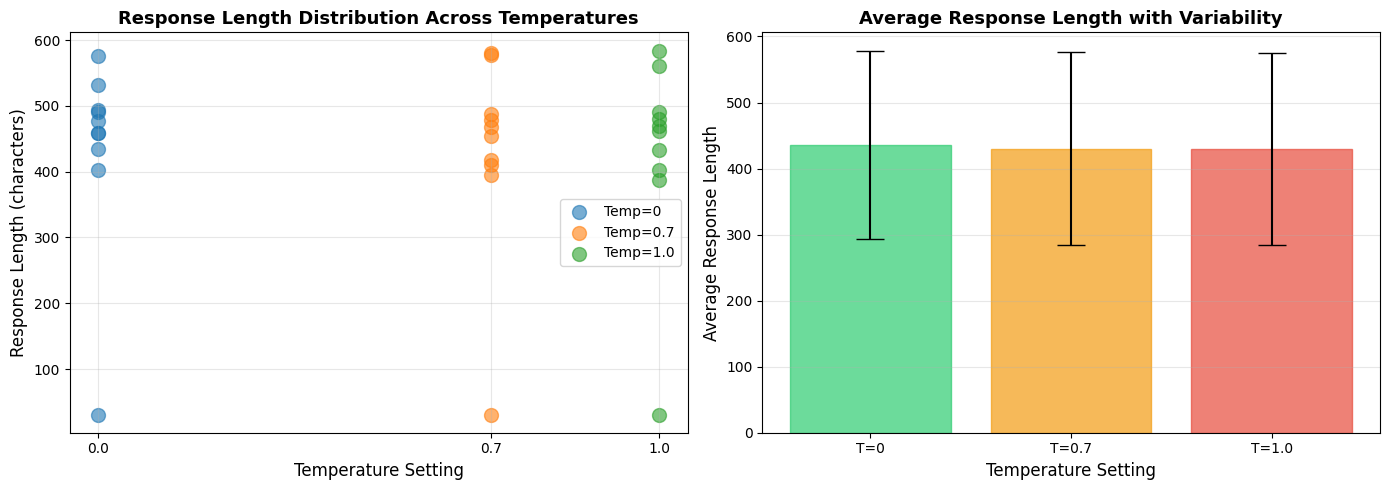


✓ Visualization complete!


In [14]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Response length distribution
for temp in temperatures:
    lengths = [len(resp) for resp in results[temp]]
    axes[0].scatter([temp] * len(lengths), lengths, alpha=0.6, s=100, label=f"Temp={temp}")

axes[0].set_xlabel("Temperature Setting", fontsize=12)
axes[0].set_ylabel("Response Length (characters)", fontsize=12)
axes[0].set_title("Response Length Distribution Across Temperatures", fontsize=13, fontweight='bold')
axes[0].set_xticks(temperatures)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average length and variability
avg_lengths = [response_lengths[temp]['avg'] for temp in temperatures]
std_lengths = [response_lengths[temp]['std'] for temp in temperatures]

bars = axes[1].bar(range(len(temperatures)), avg_lengths, yerr=std_lengths, capsize=10, alpha=0.7)
axes[1].set_xlabel("Temperature Setting", fontsize=12)
axes[1].set_ylabel("Average Response Length", fontsize=12)
axes[1].set_title("Average Response Length with Variability", fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(temperatures)))
axes[1].set_xticklabels([f"T={t}" for t in temperatures])
axes[1].grid(True, alpha=0.3, axis='y')

# Color the bars
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

## 6. Summary & Key Takeaways

### What We Learned:

**Temperature Controls Randomness:**
- **Temperature = 0** (Deterministic)
  - Always produces the exact same response
  - Best for: Factual questions, consistent outputs
  - Use case: Q&A, summarization

- **Temperature = 0.7** (Balanced) 
  - Good balance between consistency and variety
  - Best for: Most general tasks
  - Use case: Content generation, creative writing

- **Temperature = 1.0** (Creative)
  - Highly varied and unpredictable
  - Best for: Brainstorming, idea generation
  - Use case: Story writing, creative tasks

### Practical Tips:
1. Use **low temperature (0-0.3)** for data extraction and factual tasks
2. Use **medium temperature (0.5-0.8)** for general-purpose tasks
3. Use **high temperature (0.8-1.0+)** for creative and exploratory tasks
4. Always test your use case with different temperatures!

## 7. LLM Behavior Cheatsheet

### What Changes LLM Output & Why?

| Parameter | Range | What It Does | Example Effect | Use When |
|-----------|-------|-----------|-----------------|----------|
| **Temperature** | 0.0 - 1.0 | Controls randomness of token selection | Temp=0: "Paris" only; Temp=1: "Paris, City of Light, France..." | You want consistency (0) or creativity (1+) |
| **Top-P (Nucleus Sampling)** | 0.0 - 1.0 | Only sample from top P% of likely tokens | P=0.9: picks from top 90% most likely words; P=0.1: picks from only top 10% | You want quality control without randomness |
| **Top-K** | 1 - vocab_size | Only sample from top K most likely tokens | K=5: picks only from 5 most likely words; K=100: from 100 most likely | You want to prevent weird/unlikely words |
| **Frequency Penalty** | -2.0 - 2.0 | Reduces likelihood of repeating words | +1.0: strongly discourages repetition; -1.0: encourages it | You're getting repetitive outputs |
| **Presence Penalty** | -2.0 - 2.0 | Penalizes ANY mention of previously used tokens | +0.5: encourages diverse vocabulary; 0: no penalty | You want varied word choices |
| **Max Tokens** | 1 - limit | Maximum length of response | 100: max 100 tokens (~75 words); 2000: longer, detailed | You want to control response length |
| **System Prompt** | Custom text | Sets the "personality" and role of the model | "You are a pirate..." vs "You are a scientist..." | You want consistent behavior/tone |
| **Few-Shot Examples** | 0+ examples | Show the model examples of desired behavior | "Q: What is 2+2? A: 4" (demonstrates format) | You need specific output format |

---

### Quick Reference: Parameter Combinations

**For Factual Q&A:**
- Temperature: 0-0.3
- Top-P: 0.9
- Top-K: None needed
- Frequency Penalty: 0
- → Output: Consistent, accurate answers

**For Creative Writing:**
- Temperature: 0.8-1.2
- Top-P: 0.95
- Top-K: 40
- Frequency Penalty: 0.5
- → Output: Diverse, varied language

**For Code Generation:**
- Temperature: 0.2
- Top-P: 0.95
- Top-K: None needed
- Presence Penalty: 0
- → Output: Consistent syntax, no hallucinations

**For Brainstorming:**
- Temperature: 1.0+
- Top-P: 0.99
- Top-K: None
- Frequency Penalty: 0.5
- Presence Penalty: 0.1
- → Output: Many unique ideas, less repetition

---

### How These Interact:
- **Temperature** alone usually works (simple to tune)
- **Temperature + Top-P** = Fine-grained control (most common)
- **Top-K** = Emergency brake for weird outputs
- **Penalties** = Combat repetition and diversity issues
- **System Prompt + Few-Shot** = Guide behavior without parameters
